(np.float64(-0.5), np.float64(499.5), np.float64(332.5), np.float64(-0.5))

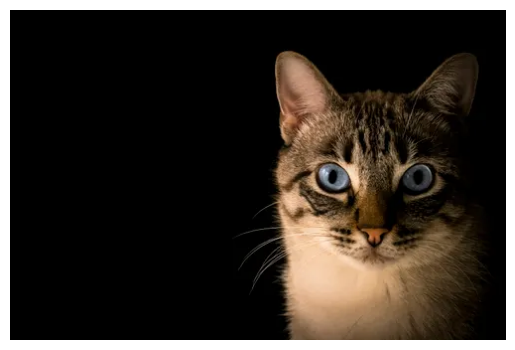

In [35]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

img = Image.open('cat.webp')
img = img.convert('RGB')
plt.imshow(img)
plt.axis('off')

In [36]:
X_img = np.array(img)
initial_shape = X_img.shape

In [37]:
X_img = X_img.reshape(-1, 3)
X_img = X_img.astype(np.float32) / 255.0
X_img.shape

(166500, 3)

In [38]:
# Step 1
def find_closest_centroids(X, centroids):
  m, n = X.shape
  K = centroids.shape[0]

  idx = np.zeros(m, dtype=int)

  for i in range(m):
    point = X[i]
    min_dist = 1e9
    closest_centroid = -1
    for j in range(K):
      centroid = centroids[j]
      sq_dist = np.sum((point - centroid) ** 2)

      if sq_dist < min_dist:
        min_dist = sq_dist
        closest_centroid = j
    idx[i] = closest_centroid

  return idx

In [39]:
# Step 2
def compute_centroids(X, idx, K):
  m, n = X.shape
  centroids = np.zeros((K, n))

  for i in range(K):
    indices = np.where(idx == i)[0]

    if len(indices):
      centroids[i] = np.mean(X[indices], axis=0)
    else:
      centroids[i] = Kmeans_init_centroids(X, 1)[0]

  return centroids

In [40]:
def Kmeans_init_centroids(X, K):
  randidx = np.random.permutation(X.shape[0])
  centroids = X[randidx[:K]]

  return centroids

In [41]:
def run_Kmeans(X, initial_centroids, max_iters):
  m, n = X.shape
  K = initial_centroids.shape[0]

  centroids = initial_centroids

  idx = np.zeros(m)

  for i in range(max_iters):
    print("K-Means iteration %d/%d" % (i, max_iters-1))

    idx = find_closest_centroids(X, centroids)
    centroids = compute_centroids(X, idx, K)

  return centroids, idx

In [42]:
K = 12 # compress into 5 colors
max_iters = 10

initial_centroids = Kmeans_init_centroids(X_img, K)

centroids, idx = run_Kmeans(X_img, initial_centroids, max_iters)

K-Means iteration 0/9
K-Means iteration 1/9
K-Means iteration 2/9
K-Means iteration 3/9
K-Means iteration 4/9
K-Means iteration 5/9
K-Means iteration 6/9
K-Means iteration 7/9
K-Means iteration 8/9
K-Means iteration 9/9


In [43]:
valid_mask = ~np.isnan(centroids).any(axis=1)
valid_centroids = centroids[valid_mask]
valid_centroids

array([[9.33288276e-01, 7.74891317e-01, 6.29497230e-01],
       [5.14633060e-01, 3.92375678e-01, 2.77685672e-01],
       [2.17326321e-02, 6.69352990e-03, 1.49412989e-03],
       [1.69749320e-01, 1.20795749e-01, 5.86421154e-02],
       [4.25136695e-03, 5.71555551e-03, 4.65667760e-03],
       [7.45098150e-05, 1.39864924e-05, 1.26166162e-06],
       [6.47550523e-01, 5.03657341e-01, 3.78273040e-01],
       [3.88915569e-01, 2.92642057e-01, 1.89735621e-01],
       [5.41669801e-02, 2.62275841e-02, 6.52752584e-03],
       [2.65025556e-01, 1.98722959e-01, 1.17375635e-01],
       [1.02277130e-01, 6.37935922e-02, 1.94469113e-02],
       [7.88259327e-01, 6.22823000e-01, 4.80321169e-01]])

In [44]:
X_img_compressed = centroids[idx]
X_img_compressed = (X_img_compressed * 255).round().astype(np.uint8)

In [45]:
X_img_compressed = X_img_compressed.reshape(initial_shape)

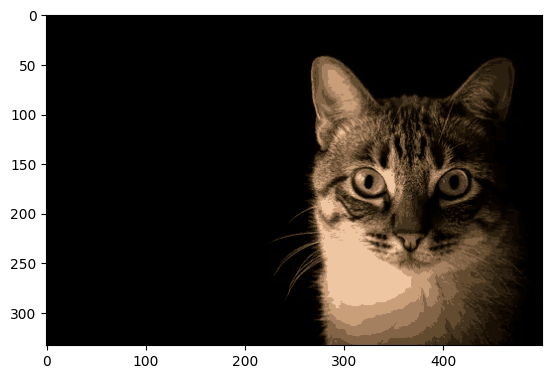

In [46]:
plt.imshow(X_img_compressed.astype(np.uint8))

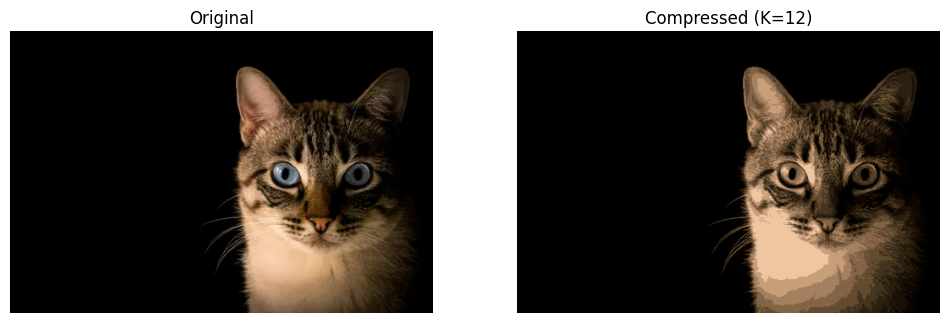

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis('off')
axes[1].imshow(X_img_compressed.astype(np.uint8))
axes[1].set_title("Compressed (K=12)")
axes[1].axis('off')
plt.savefig("comparison.png", bbox_inches='tight')
plt.show()